In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# creating gates
from quantum_logical.gate_extender import Gate_extender, Convert_levels
dim = 2
N = 5
# creating the set of cnots (this will operate between the g and e levels)
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)
 
cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

# the x_gate needs to be made in a qutrit gate and will involve conversion 
x_gate = qt.Qobj([[0, 1],[1, 0]])
z_gate = 1/np.sqrt(3) * qt.Qobj([[1, 0, 0],[0, 1, 0], [0, 0, -1]])

# hadamard gate
hada = 1/np.sqrt(3) * qt.Qobj([[-1/2 + np.sqrt(3)*1j/2, 1, -1/2 - np.sqrt(3)*1j/2], [1, 1, 1], [-1/2 - np.sqrt(3)*1j/2, 1, -1/2 + np.sqrt(3)*1j/2]])

# new set of qutrit gates 
# extension of the gates into the qutrit space 
# need to make the gate extender take the individual qudit counts at every instance 
gate_extention = Gate_extender(num_qubits=1)
x_gate, new_dim = gate_extention.qubit_to_qudit(gate=x_gate, from_dim=dim, to_dim=3)
gate_extention = Gate_extender(num_qubits=N)
cnot1, new_dim = gate_extention.qubit_to_qudit(gate=cnot1, from_dim=dim, to_dim=3)
cnot2, new_dim = gate_extention.qubit_to_qudit(gate=cnot2, from_dim=dim, to_dim=3)
cnot3, new_dim = gate_extention.qubit_to_qudit(gate=cnot3, from_dim=dim, to_dim=3)
cnot4, new_dim = gate_extention.qubit_to_qudit(gate=cnot4, from_dim=dim, to_dim=3)
cnot5, new_dim = gate_extention.qubit_to_qudit(gate=cnot5, from_dim=dim, to_dim=3)
cnot6, new_dim = gate_extention.qubit_to_qudit(gate=cnot6, from_dim=dim, to_dim=3)

# conversion of some of the gates into the qutrit space 
converter = Convert_levels(num_qubits=1)
x_gate = converter.level_conversion(levels=[0,2], dim=new_dim, gate=x_gate)
converter = Convert_levels(num_qubits=N)
cnot1= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot1)
cnot2= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot2)

x_layer = tensor(tensor([x_gate] * 3), tensor([qt.qeye(new_dim)] * 2))
hada_layer = tensor(tensor([hada] * 3), tensor([qt.qeye(new_dim)] * 2))

C:\Users\girgi\AppData\Local\Temp\ipykernel_11652\706904431.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_11652\706904431.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_11652\706904431.py:9: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [3]:
# create fidelity function
# add others if you want another metric 
def hilbert_schmidt_fid_func(rho, sigma):
    return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

x_gate

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

In [4]:
# not satisfied with the correction there has to be more that can be done because right now this is not good 
# do the whole thing with some decayed state out and see what the result should be 
correction_x = qt.Qobj([[0, 1],[1, 0]])
gate_extention = Gate_extender(num_qubits=1)
correction_x, new_dim = gate_extention.qubit_to_qudit(gate=correction_x, from_dim=dim, to_dim=3)
converter = Convert_levels(num_qubits=1)
correction_x = converter.level_conversion(levels=[1,2], dim=new_dim, gate=correction_x)

In [5]:
correction_x

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

In [7]:
# generating parameters and creating initial state
T1 = 80
T2 = 80

dim = new_dim
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")

In [8]:
# creating initial state
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 2)).unit(), tensor([basis(dim, 0)] * (N-1)))
# psi0 = tensor(tensor([basis(dim, 2)] * 2), tensor([basis(dim, 0)] * 3)) # used as a sanity check on the ideal setup to test the created gates
rho0 = psi0 * psi0.dag()
rho_encoded = hada_layer * cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag() * hada_layer.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation
# qt.ptrace(rho0, [0,1,2])

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.03703704+0.j         -0.01851852-0.03207501j -0.01851852+0.03207501j
  -0.01851852-0.03207501j -0.01851852+0.03207501j  0.03703704+0.j
  -0.01851852+0.03207501j  0.03703704+0.j         -0.01851852-0.03207501j
  -0.01851852-0.03207501j -0.01851852+0.03207501j  0.03703704+0.j
  -0.01851852+0.03207501j  0.03703704+0.j         -0.01851852-0.03207501j
   0.03703704+0.j         -0.01851852-0.03207501j -0.01851852+0.03207501j
  -0.01851852+0.03207501j  0.03703704+0.j         -0.01851852-0.03207501j
   0.03703704+0.j         -0.01851852-0.03207501j -0.01851852+0.03207501j
  -0.01851852-0.03207501j -0.01851852+0.03207501j  0.03703704+0.j        ]
 [-0.01851852+0.03207501j  0.03703704+0.j         -0.01851852-0.03207501j
   0.03703704+0.j         -0.01851852-0.03207501j -0.01851852+0.03207501j
  -0.01851852-0.03207501j -0.01851852+0.03207501j  0.03703704+0.j
   0.03703704+0.j         -0.01

this needs to be fixed today 

In [9]:
# build circuit 
# this needs to be reoptimized for the x_gates at the proper time 
# CNOT gates 
states = []
fids = []
states.append(rho_encoded)
fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, rho_encoded_traced))
# cnot_duration = .5
time_list = [ .001, .025, .5, .5, .5, .5, .025, .001]
cnot_list = [hada_layer, x_layer, cnot3, cnot5, cnot4, cnot6, x_layer, hada_layer]
# CNOT gate execution
rho_cnot = rho_encoded
for i in tqdm(range(len(cnot_list))):
    cnot_states = trotter.apply(rho_cnot, duration=time_list[i], unitary=[cnot_list[i]])
    if i in [0, len(cnot_list)-1]:
        states.extend(cnot_states)
    else:
        states.extend(hada_layer * cnot_states * hada_layer.dag())
    states.extend(cnot_states)
    for j in range(len(cnot_states)):
        if i not in [0, len(cnot_list)-1]:
            fids.append(hilbert_schmidt_fid_func(qt.ptrace(hada_layer * cnot_states[j] * hada_layer.dag(), [0,1,2]), rho_encoded_traced))
        else:
            fids.append(hilbert_schmidt_fid_func(qt.ptrace(cnot_states[j], [0,1,2]), rho_encoded_traced))
    rho_cnot = cnot_states[-1]

100%|██████████| 8/8 [00:13<00:00,  1.64s/it]


the hadamards now apply and they work but need to fix the issue where i can not give them the appropriate time length (small issue do not waste much time on it now)

In [10]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .025
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=[recovery_ops[i]])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

total_time = sum(time_list) + duration_recovery

[0.9999966814898974, 1.1113705854234364e-06, 1.105677088466162e-06, 1.1014624286709401e-06]


[0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405, 0.03703024674047405]


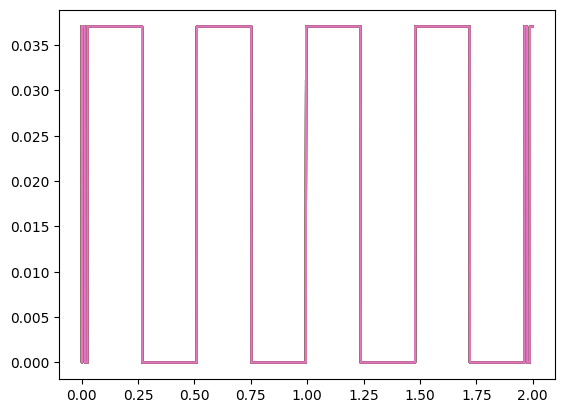

In [11]:
# plotting to see the states 
time = np.linspace(0, 2, len(states))
fig, ax = plt.subplots()
state = []
populations = []
for i in states:
    state.append(qt.ptrace(i, [0,1,2]))
for j in range(dim ** 3):
    data = []
    for i in range(len(state)):
        data.append(np.abs(state[i][26,26]))
    populations.append(data[-1])
    ax.plot(time, data)
print(populations)

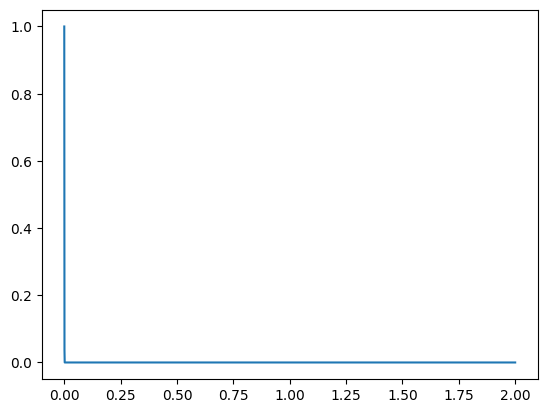

In [12]:
time = np.linspace(0, 2, len(fids))
fig, ax = plt.subplots()
ax.plot(time, fids)


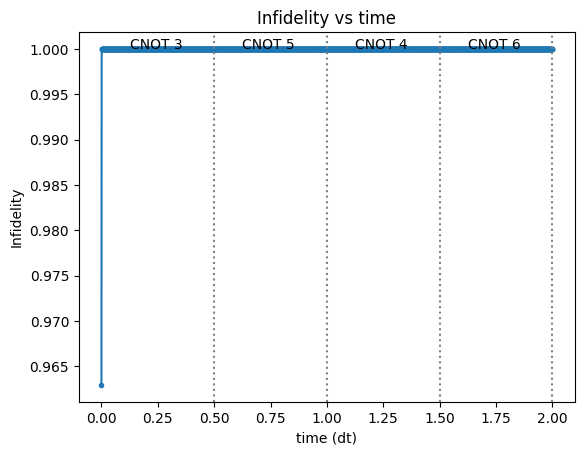

In [12]:
# fidelity plot 
infid = [(1-fid) for fid in fids]
# plot fidelity 
fig, ax = plt.subplots()
ax.plot(time, infid, marker = ".")
ax.set_title("Infidelity vs time")
ax.set_ylabel("Infidelity")
ax.set_xlabel("time (dt)")
plt.ticklabel_format(style='plain')
x = [.5, 1, 1.5, 2]
plt.text(.125, max(infid), 'CNOT 3')
plt.text(.625, max(infid), 'CNOT 5')
plt.text(1.125, max(infid), 'CNOT 4')
plt.text(1.625, max(infid), 'CNOT 6')
# plt.text(2.125, max(infid), 'Recovery')
plt.xlim(-.1, 2.1)
for i in x:
    plt.axvline(x=i, color='gray', linestyle=':')

In [13]:
infid[-1]

0.9999999999978466